# Assignment Solutions: Intro to Machine Learning

This notebook answers both assignment exercises:
1. Linear Regression on California Housing
2. Classification on Breast Cancer (Logistic Regression vs KNN)

In [2]:
# Common imports used in both exercises
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

## 1. Linear Regression Exercise (California Housing)

In [3]:
from sklearn.datasets import fetch_california_housing

# Load the California housing dataset from scikit-learn
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Split into train/test so we evaluate on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict house prices on the test set
y_pred = lin_reg.predict(X_test)

# Evaluate with MSE and R^2 to measure error and fit quality
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression MSE: {mse:.4f}")
print(f"Linear Regression R^2: {r2:.4f}")

Linear Regression MSE: 0.5559
Linear Regression R^2: 0.5758


### Interpreting the Linear Regression Output

- `MSE = 0.5559`: On average, the squared prediction error is about `0.556` in target units squared. Lower MSE means better predictions.
- `R^2 = 0.5758`: The model explains about **57.58%** of the variance in house prices on the test set.

This indicates the model has **moderate predictive power**: it captures a meaningful part of the price pattern, but there is still substantial unexplained variation (about 42.42%), likely due to non-linear effects or features not captured well by a simple linear model.

## 2. Classification Exercise (Breast Cancer)

Compare **Logistic Regression** and **KNN** on the same train/test split.

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load breast cancer data (target: malignant vs benign)
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Stratify keeps class ratio similar in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features because distance-based models (like KNN) are sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)

# KNN model (k=5 is a common baseline choice)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Logistic Regression Accuracy: {acc_log:.4f}")
print(f"KNN Accuracy:                {acc_knn:.4f}")

print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_log, target_names=cancer.target_names))

print("KNN Report:")
print(classification_report(y_test, y_pred_knn, target_names=cancer.target_names))

Logistic Regression Accuracy: 0.9825
KNN Accuracy:                0.9561

Logistic Regression Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

KNN Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Best k: 3
Best validation accuracy: 0.9649


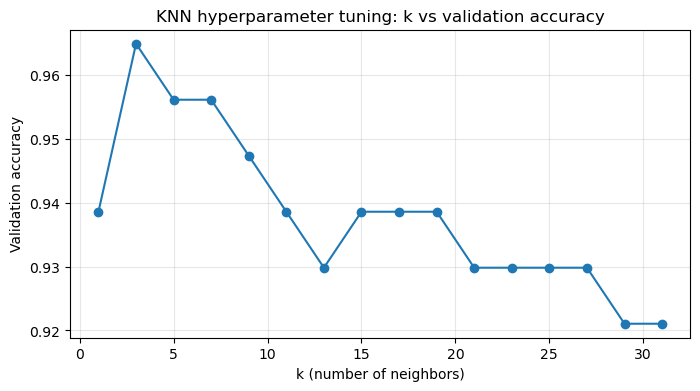

Final test accuracy with best k: 0.9825


In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1) Split: train/val/test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)  # 0.25 of 0.8 = 0.2

# 2) Scale using train only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# 3) Try multiple k values
k_values = range(1, 32, 2)   # odd k to reduce ties
val_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    y_val_pred = model.predict(X_val_s)
    val_accuracies.append(accuracy_score(y_val, y_val_pred))

# 4) Find best k
best_idx = int(np.argmax(val_accuracies))
best_k = list(k_values)[best_idx]
best_val_acc = val_accuracies[best_idx]

print("Best k:", best_k)
print("Best validation accuracy:", round(best_val_acc, 4))

# 5) Plot k vs validation accuracy
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), val_accuracies, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Validation accuracy")
plt.title("KNN hyperparameter tuning: k vs validation accuracy")
plt.grid(True, alpha=0.3)
plt.show()

# 6) Optional: final test evaluation with best k
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(np.vstack([X_train_s, X_val_s]), np.hstack([y_train, y_val]))
y_test_pred = final_knn.predict(X_test_s)
test_acc = accuracy_score(y_test, y_test_pred)
print("Final test accuracy with best k:", round(test_acc, 4))

## Peer Review Note from Soon:

I have not checked the housing dataset yet. But on the cancer dataset, there are some suggestions for your reference:
(1) Though k=5 can be used as benchmark, but the optimal k value can be found by plotting k against the respective accuracy of each k. In this case, the optimal k value is found to be 3 with an accuracy of 0.9825 which is comparable to that of the Logistic Regression.

[Fred] Verified above, k=3 gave an accuracy same as Logistic Regression.

(2) Usually for dataset relating to healthcare, the data may be imbalanced. In the cancer dataset, we have about 62.7% benign and 37.3% malignant cases. The better metric for assessing model performance should be Recall (catching all actual cancer cases) is often more important than overall accuracy.
(3) Since the dataset is small and imbalanced, perhaps the stratified K-fold cross-validation may be a more consistent and better option for training/validation/test data split.

1) Cross-validate a fixed KNN (e.g., (k=5))

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Data
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Stratified folds keep class ratio similar in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scale + KNN in one pipeline (no leakage)
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

# Use metrics suited for imbalance
scores = cross_validate(
    knn_pipe,
    X, y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_acc": "balanced_accuracy",
        "recall_malignant": "recall",   # positive class = 1 by default in this dataset
        "f1": "f1"
    }
)

for m in scores:
    if m.startswith("test_"):
        print(f"{m}: mean={np.mean(scores[m]):.4f}, std={np.std(scores[m]):.4f}")

test_accuracy: mean=0.9666, std=0.0171
test_balanced_acc: mean=0.9590, std=0.0233
test_recall_malignant: mean=0.9888, std=0.0104
test_f1: mean=0.9740, std=0.0131


2) Tune (k) with stratified CV (recommended)

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {"knn__n_neighbors": list(range(1, 32, 2))}
grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="recall",   # or "f1", "balanced_accuracy", depending on objective
    n_jobs=-1
)

grid.fit(X, y)

print("Best k:", grid.best_params_["knn__n_neighbors"])
print("Best CV recall:", round(grid.best_score_, 4))

Best k: 27
Best CV recall: 0.9972


## Quick Comparison

Use the printed accuracy scores to decide which model performed better on this split.

## Model Comparison Decision (This Split)

Based on the printed test accuracies:

- Logistic Regression Accuracy = **0.9825**
- KNN Accuracy = **0.9561**

**Decision:** Logistic Regression performed better on this train/test split.

Why:
- Logistic Regression has the higher overall accuracy.
- Its class-wise precision/recall/F1 are also slightly higher for both `malignant` and `benign` classes.[^2]

### What `random_state=42` does in this notebook

In `train_test_split(..., random_state=42)`, the value `42` is a fixed seed for the random number generator.

- It makes the train/test split **reproducible**.
- If you run the notebook again with the same data and same seed, you get the **same rows** in train and test.
- This is useful for fair model comparison, because Logistic Regression and KNN are evaluated on exactly the same test set.
- If you change or remove the seed, the split can change, and your accuracy numbers may change too.

Note: This conclusion is for this specific split (`random_state=42`). For a more robust comparison, use cross-validation across multiple splits.[^1]

[^1]: The number `42` has no special mathematical meaning here. Any fixed integer (for example, `0`, `7`, or `123`) works; one fixed value was used so results are consistent and repeatable.

[^2]: **Precision**: Of predictions labeled as a class, how many were correct? **Recall**: Of actual instances of a class, how many did the model catch? **F1**: The harmonic mean of precision and recall, balancing both metrics. For example, a precision of 0.98 means 98% of predicted malignant cases were actually malignant; a recall of 0.98 means the model correctly identified 98% of actual malignant cases.

## Appendix: Scikit-Learn Libraries Used in This Assignment

This section explains the sklearn modules and classes imported and used throughout the assignment.

### Data Handling

**`train_test_split`** (from `sklearn.model_selection`)
- **Purpose**: Splits a dataset into training and testing subsets.
- **Usage**: `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`
- **Parameters**: 
  - `test_size=0.2`: Uses 20% for testing, 80% for training.
  - `random_state=42`: Ensures reproducible splits.
  - `stratify=y`: (in classification) Keeps class proportions balanced.
- **Why**: Prevents overfitting by evaluating on unseen data.

### Model Classes

**`LinearRegression`** (from `sklearn.linear_model`)
- **Purpose**: Fits a linear regression model for regression tasks.
- **Usage**: `lin_reg = LinearRegression()` then `lin_reg.fit(X_train, y_train)`
- **Methods**:
  - `.fit()`: Trains the model.
  - `.predict()`: Makes predictions on new data.
- **Application**: Predicting continuous values like house prices.

**`LogisticRegression`** (from `sklearn.linear_model`)
- **Purpose**: Fits a logistic regression model for binary/multiclass classification.
- **Usage**: `log_reg = LogisticRegression(max_iter=2000, random_state=42)` then `.fit()` and `.predict()`
- **Parameter**: `max_iter=2000` increases iterations for convergence.
- **Application**: Predicting class labels like malignant vs benign.

**`KNeighborsClassifier`** (from `sklearn.neighbors`)
- **Purpose**: Implements the K-Nearest Neighbors algorithm for classification.
- **Usage**: `knn = KNeighborsClassifier(n_neighbors=5)` then `.fit()` and `.predict()`
- **Parameter**: `n_neighbors=5` uses 5 nearest neighbors for each prediction.
- **Application**: Instance-based learning approach, compared against Logistic Regression.

### Evaluation Metrics

**`mean_squared_error`** (from `sklearn.metrics`)
- **Purpose**: Calculates the mean squared error between actual and predicted values.
- **Usage**: `mse = mean_squared_error(y_test, y_pred)`
- **Interpretation**: Lower values indicate better predictions. Used for regression models.

**`r2_score`** (from `sklearn.metrics`)
- **Purpose**: Calculates the R-squared (coefficient of determination) score.
- **Usage**: `r2 = r2_score(y_test, y_pred)`
- **Interpretation**: Ranges from 0 to 1; higher values indicate better fit. Measures percentage of variance explained.

**`accuracy_score`** (from `sklearn.metrics`)
- **Purpose**: Calculates classification accuracy (fraction of correct predictions).
- **Usage**: `acc = accuracy_score(y_test, y_pred)`
- **Interpretation**: Ranges from 0 to 1. Higher is better. Works for both binary and multiclass.

**`classification_report`** (from `sklearn.metrics`)
- **Purpose**: Generates a detailed classification report with precision, recall, and F1-score per class.
- **Usage**: `print(classification_report(y_test, y_pred, target_names=cancer.target_names))`
- **Output**: Shows precision, recall, F1, and support for each class, aiding in detailed model evaluation.

### Data Preprocessing

**`StandardScaler`** (from `sklearn.preprocessing`)
- **Purpose**: Standardizes features by removing mean and scaling to unit variance.
- **Usage**: `scaler = StandardScaler()` then `X_scaled = scaler.fit_transform(X)` and `X_test_scaled = scaler.transform(X_test)`
- **Why**: Distance-based models (like KNN) are sensitive to feature scale. Scaling ensures fair weighting.
- **Note**: `.fit_transform()` on train data, `.transform()` on test to avoid data leakage.